In [41]:
import sys
sys.path.insert(0, '/home/jonathan/Documents/mi3-gs/build/python')

import drjit as dr
from drjit.auto.ad import Float, UInt, Bool
import mitsuba as mi
mi.set_variant('cuda_ad_rgb')

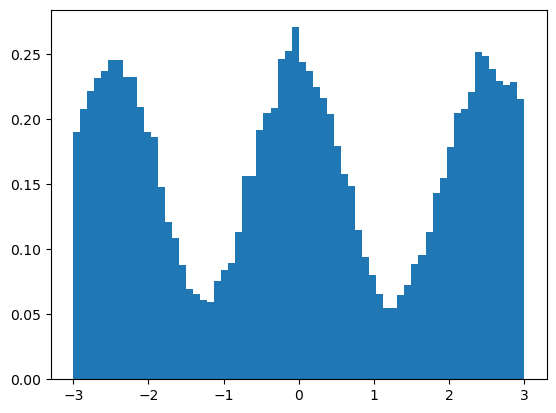

In [42]:
class ReservoirFloat:
    DRJIT_STRUCT = {
        'sample': Float,
        'valid': bool,
        'w_sum': Float,
    }

    def __init__(self, size: int):
        self.sample = dr.zeros(Float, size)
        
        self.valid = dr.full(Bool, False, size)
        self.w_sum = dr.zeros(Float, size)

    def add_proposal(self, sample: Float, rand: Float, wi: Float):
        self.w_sum += wi
        self.sample = dr.select(rand < wi * dr.rcp(self.w_sum), sample, self.sample)
        self.valid |= wi > 0.0

    def get(self):
        return self.sample, self.valid


N = 1 << 15
M_mat = 8
sampler = mi.load_dict({'type': 'independent'})
sampler.seed(0, N)

r = ReservoirFloat(N)
for _ in range(M_mat):
    xs = 3.0 * (2.0 * sampler.next_1d() - 1.0)
    weight = (dr.cos(2.5 * xs) + 1.5) / (1.0 / 6.0)
    r.add_proposal(xs, sampler.next_1d(), weight)


import matplotlib.pyplot as plt
plt.hist(r.sample.numpy(), density=True, bins=64);

In [43]:
scene_dict = mi.cornell_box()
scene_dict['sensor']['film']['rfilter']['type'] = 'box'
scene_dict['sensor']['film']['width'] =  256
scene_dict['sensor']['film']['height'] = 256
scene_dict['integrator']['max_depth'] = 2
scene: mi.Scene = mi.load_dict(scene_dict)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].


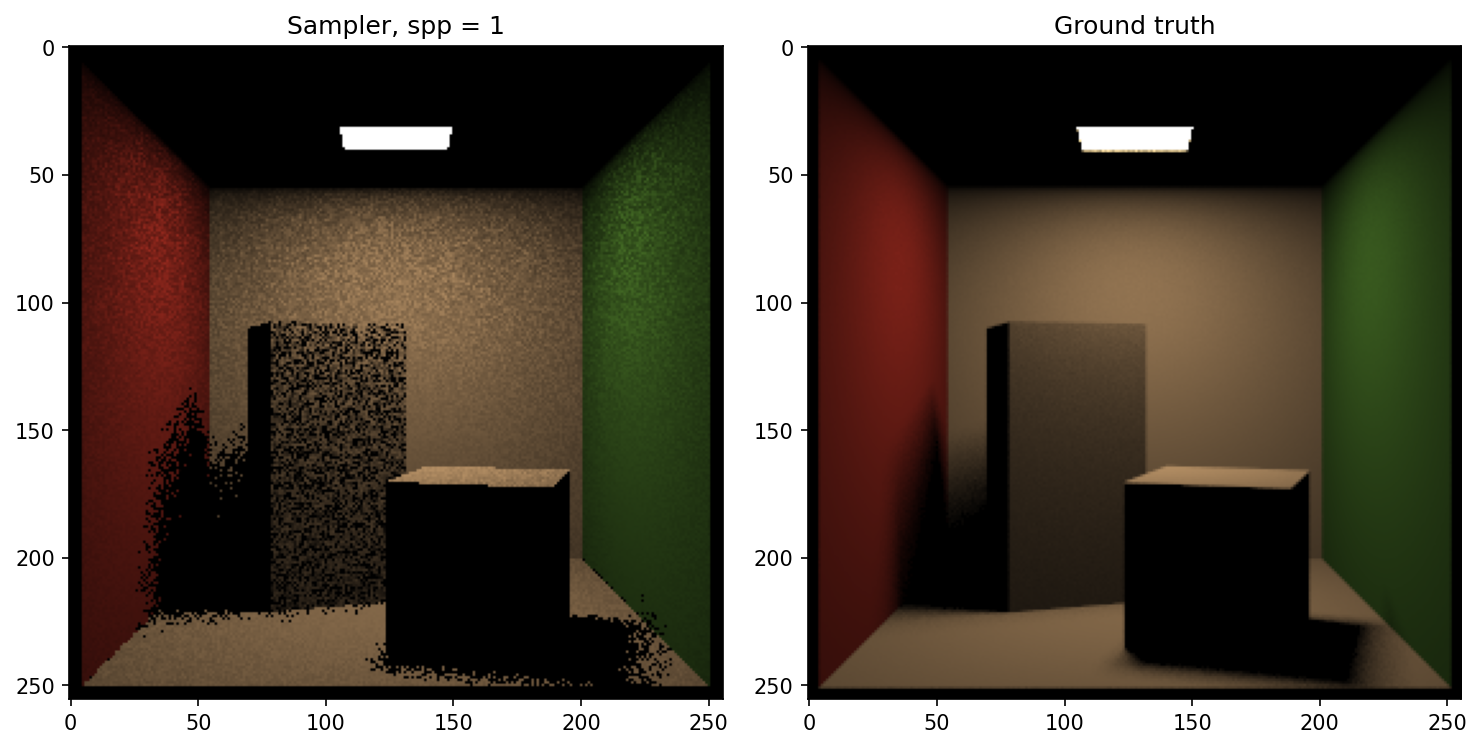

In [44]:
from mitsuba.ad.integrators.common import mis_weight as power_heuristic

def integrator_sample(
        scene: mi.Scene, 
        sampler: mi.Sampler, 
        rays: mi.Ray3f, 
        ):
    ctx = mi.BSDFContext()
    si = scene.ray_intersect(rays)

    # Direct hit on emitter
    result: mi.Color3f = dr.select(si.emitter(scene) != None, si.emitter(scene).eval(si), mi.Color3f(0.0))

    # ---------------------- BSDF sampling ----------------------
    bsdf = si.bsdf(rays)
    bsdf_sample, bsdf_val_rcp_pdf = bsdf.sample(ctx, si, sampler.next_1d(), sampler.next_2d())

    # Evaluate emitter contribution along BSDF-sampled ray
    em_ray = si.spawn_ray(si.to_world(bsdf_sample.wo))
    em_si = scene.ray_intersect(em_ray)

    active_bsdf = (em_si.emitter(scene) != None)
    ds = mi.DirectionSample3f(scene, em_si, si)
    em_pdf = scene.pdf_emitter_direction(si, ds, active_bsdf)

    # Compute MIS weight
    mis_bsdf = power_heuristic(bsdf_sample.pdf, em_pdf)

    # Accumulate
    result += dr.select(active_bsdf,
                        bsdf_val_rcp_pdf * ds.emitter.eval(em_si, bsdf_sample.pdf > 0.0) * mis_bsdf, 
                        0.0)

    # ---------------------- Emitter sampling ----------------------
    # Sample the emitter
    ds, em_val_rcp_pdf = scene.sample_emitter_direction(
        si, sampler.next_2d(), True)
    active_em = (ds.pdf != 0.0)
    wo = si.to_local(ds.d)

    # Evaluate BSDF * cos(theta) and pdf
    bsdf_val, bsdf_pdf = bsdf.eval_pdf(ctx, si, wo)

    # Compute the MIS weight
    mis_em = power_heuristic(ds.pdf, bsdf_pdf)

    # Accumulate, being careful with polarization (see spec_fma)
    result += dr.select(active_em,
                        bsdf_val * em_val_rcp_pdf * mis_em,
                        0.0)

    # ------ Finalize ------
    return dr.select(si.is_valid(), result, 0.0)


em: mi.Emitter = scene.emitters()[0]
sensor: mi.Sensor = scene.sensors()[0]
Ny, Nx = sensor.film().size()
N = Ny * Nx
uu, vv = dr.meshgrid(
    dr.linspace(Float, 0.0, 1.0, Ny), 
    dr.linspace(Float, 0.0, 1.0, Nx))
rays = sensor.sample_ray(0.0, 0.0, mi.Point2f(uu, vv), dr.zeros(mi.Point2f, N))[0]
sampler = mi.load_dict({'type': 'independent'})
sampler.seed(0, N)

spp = 1
image = dr.zeros(mi.Color3f, N)
for _ in range(spp):
    image += integrator_sample(scene, sampler, rays) / spp

img_out = mi.TensorXf(dr.ravel(image), shape=(Nx, Ny, 3))
img_gt = mi.render(scene, spp=256)

plt.figure(figsize=(10, 5), dpi=150)
plt.subplot(121); plt.imshow((img_out) ** (1 / 2.2)); plt.title(f"Sampler, spp = {spp}")
plt.subplot(122); plt.imshow((img_gt)  ** (1 / 2.2)); plt.title("Ground truth")
plt.tight_layout()

mi.util.write_bitmap("cornell_gt.exr", img_gt)
mi.util.write_bitmap("cornell_custom.exr", img_out)

In [76]:
class ReservoirDirectionSample3f:
    DRJIT_STRUCT = {
        'sample': mi.DirectionSample3f,
        'valid': bool,
        'w_sum': Float,
        'p_hat': Float,
        'c': Float,
    }

    def __init__(self, size: int):
        self.sample = dr.zeros(mi.DirectionSample3f, size)
        self.valid = dr.full(Bool, False, size)
        self.w_sum = dr.zeros(Float, size)
        self.p_hat = dr.zeros(Float, size)
        self.c     = dr.zeros(Float, size)

    def add_proposal(self, sample: mi.DirectionSample3f, rand: Float, weight: Float, confidence: float = 1.0):
        C_CAP = 100.0
        self.w_sum += weight
        cond = (self.w_sum > 0.0) & (rand < weight * dr.rcp(self.w_sum))
        self.sample = dr.select(cond, sample, self.sample)
        self.valid |= weight > 0.0
        self.c = dr.minimum(self.c + confidence, C_CAP)
    
    def size(self):
        return dr.width(self.sample)
    
    # def get_sample(self):
    #     w_sum = dr.select(self.valid, self.w_sum, 0.0)
    #     return self.sample, w_sum

    def eval_target(self, eval_target_function):
        self.p_hat = dr.select(self.valid, eval_target_function(self.sample), 0.0)

    def get_sample(self, eval_target):
        p_hat = dr.select(self.valid, eval_target(self.sample), 0.0)
        W = dr.select(p_hat > 0.0, self.w_sum * dr.rcp(p_hat), 0.0)
        self.p_hat = p_hat
        return self.sample, W
    
    def reinitialize(self, mis_weight):
        # # update sample; no-op
        # self.sample = self.sample

        # update `w_sum`
        self.w_sum = dr.select(self.p_hat > 0.0, mis_weight * self.w_sum, 0.0)

        # p_hat = dr.select(self.w_sum > 0.0, eval_target(ds), 0.0)
        # contrib_weight = dr.select(p_hat > 0.0, self.w_sum / p_hat, 0.0)   # == "big W"
        # self.w_sum = mis_weight * p_hat * contrib_weight

        # update `valid`
        self.valid = self.w_sum > 0.0

In [32]:
def eval_target_function(ds: mi.DirectionSample3f, si: mi.SurfaceInteraction3f, bsdf: mi.BSDF):
        em_val = ds.emitter.eval_direction(si, ds)
        wo = si.to_local(ds.d)
        p_hat = bsdf.eval(mi.BSDFContext(), si, wo) * em_val
        return dr.max(p_hat, axis=0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].


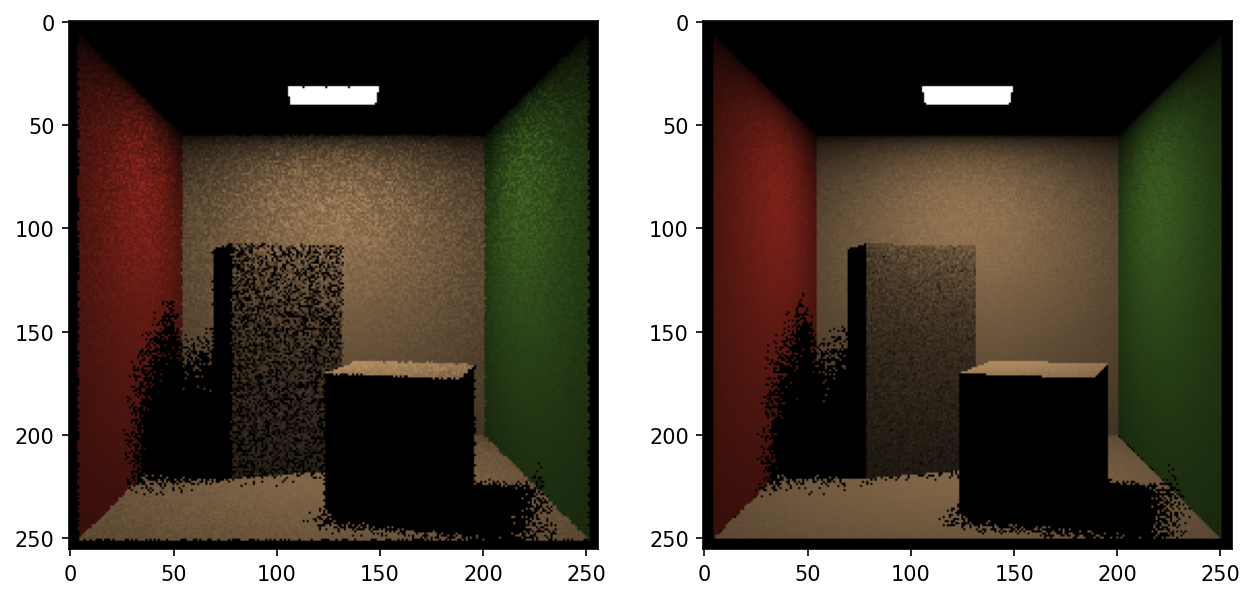

In [33]:
def integrator_sample_RIS_em(
        scene: mi.Scene, 
        sampler: mi.Sampler, 
        rays: mi.Ray3f, 
        M_em: int
        ):
    ctx = mi.BSDFContext()
    si = scene.ray_intersect(rays)
    active = si.is_valid()
    bsdf = si.bsdf(rays)

    rsv = ReservoirDirectionSample3f(dr.width(rays))

    # Handle direct hit on emitter
    result: mi.Color3f = dr.select(si.emitter(scene) != None, si.emitter(scene).eval(si), mi.Color3f(0.0))

    # --------------- Sample generation for emitters ---------------
    for _ in range(M_em):
        # Draw an emitter sample, `s`, *without* visibility test
        ds_sample = scene.sample_emitter_direction(
            si, sampler.next_2d(), False)[0]
        # Contrib. weight of drawn sample, `s.W`
        ds_W = dr.rcp(ds_sample.pdf)
        # Compute target function *without* visibility
        em_val = ds_sample.emitter.eval_direction(si, ds_sample)
        p_hat = bsdf.eval(ctx, si, si.to_local(ds_sample.d)) * em_val

        # TODO: had to take the max component of `p_hat` since it contains color values
        p_hat = dr.max(p_hat, axis=0)
        # Compute weight `w`
        mis_weight = 1.0 / M_em
        w = dr.select(ds_sample.pdf > 0.0, p_hat * ds_W * mis_weight, 0.0)      # 50:13
        # Add sample to reservoir
        rsv.add_proposal(ds_sample, sampler.next_1d(), w)
        
    ds, contrib_weight = rsv.get_sample(lambda ds: eval_target_function(ds, si, bsdf))
    # em_val = ds.emitter.eval_direction(si, ds)
    wo = si.to_local(ds.d)
    # # TODO: had to take the max component of `p_hat` since it contains color values
    # p_hat = dr.max(bsdf.eval(ctx, si, wo) * em_val, axis=0)
    # contrib_weight = dr.select(p_hat > 0.0, w_sum / p_hat, 0.0)   # == "big W"

    # --------------------- Evaluate integrand ----------------------
    bsdf_val = bsdf.eval(ctx, si, wo)
    Le_val = ds.emitter.eval_direction(si, ds)
    # Evaluate visibility
    occluded = scene.ray_test(si.spawn_ray_to(ds.p))
    integrand = dr.select(~occluded, bsdf_val * Le_val, mi.Color3f(0.0))
    result += dr.select(active, integrand * contrib_weight, 0.0)

    # # ------ Finalize ------
    return dr.select(si.is_valid(), result, 0.0)


M_em = 8
rays = sensor.sample_ray(0.0, 0.0, mi.Point2f(uu, vv), dr.zeros(mi.Point2f, N))[0]
sampler = mi.load_dict({'type': 'independent'})
sampler.seed(0, N)

image = integrator_sample_RIS_em(scene, sampler, rays, M_em)
img_ris_em = mi.TensorXf(dr.ravel(image), shape=(Nx, Ny, 3))
mi.util.write_bitmap(f"cornell_ris_em={M_em}.exr", img_ris_em)


plt.figure(figsize=(10, 5), dpi=150)
img_gt_1 = mi.render(scene, spp=1)
mi.util.write_bitmap("cornell_gt_1.exr", img_gt_1)
plt.subplot(121); plt.imshow(img_gt_1 ** (1 / 2.2))
plt.subplot(122); plt.imshow(img_ris_em ** (1 / 2.2))


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].


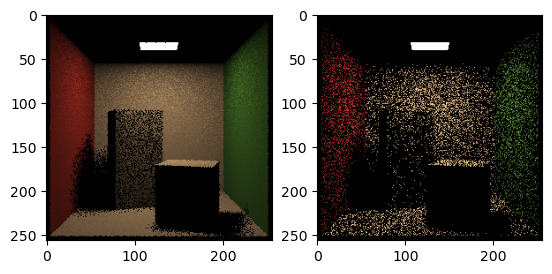

In [8]:
def integrator_sample_RIS_mat(
        scene: mi.Scene, 
        sampler: mi.Sampler, 
        rays: mi.Ray3f, 
        M_mat: int
        ):
    ctx = mi.BSDFContext()
    si = scene.ray_intersect(rays)
    active = si.is_valid()
    bsdf = si.bsdf(rays)

    rsv = ReservoirDirectionSample3f(dr.width(rays))

    # Direct hit on emitter
    result: mi.Color3f = dr.select(si.emitter(scene) != None, si.emitter(scene).eval(si), mi.Color3f(0.0))

    # --------------- Sample generation for BSDF ---------------
    for _ in range(M_mat):
        # Draw a BSDF sample
        bsdf_sample = bsdf.sample(ctx, si, sampler.next_1d(), sampler.next_2d())[0]
        bsdf_val, bsdf_pdf = bsdf.eval_pdf(ctx, si, bsdf_sample.wo)
        # Contrib. weight of drawn sample, `s.W`
        bsdf_W = dr.rcp(bsdf_pdf)
        # Compute target function *without* visibility
        em_ray = si.spawn_ray(si.to_world(bsdf_sample.wo))
        em_si = scene.ray_intersect(em_ray)
        ds = mi.DirectionSample3f(scene, em_si, si)
        em_val = scene.eval_emitter_direction(si, ds)
        # TODO: had to take the max component of `p_hat` since it contains color values
        p_hat = dr.max(bsdf_val * em_val, axis=0)

        # Compute weight `w`
        mis_weight = 1.0 / M_mat
        w = dr.select(bsdf_pdf > 0.0, p_hat * bsdf_W * mis_weight, 0.0)      # 50:13
        # Add sample to reservoir
        rsv.add_proposal(ds, sampler.next_1d(), w)
        
    ds, w_sum = rsv.get_sample()
    em_val = ds.emitter.eval_direction(si, ds)
    wo = si.to_local(ds.d)
    # TODO: had to take the max component of `p_hat` since it contains color values
    p_hat = dr.max(bsdf.eval(ctx, si, wo) * em_val, axis=0)
    contrib_weight = dr.select(p_hat > 0.0, w_sum / p_hat, 0.0)   # == "big W"

    # --------------------- Evaluate integrand ----------------------
    bsdf_val = bsdf.eval(ctx, si, wo)
    Le_val = ds.emitter.eval_direction(si, ds)
    # Evaluate visibility
    occluded = scene.ray_test(si.spawn_ray_to(ds.p))
    integrand = dr.select(~occluded, bsdf_val * Le_val, mi.Color3f(0.0))
    result += dr.select(active, integrand * contrib_weight, 0.0)

    # # ------ Finalize ------
    return dr.select(si.is_valid(), result, 0.0)

M_mat = 32
rays = sensor.sample_ray(0.0, 0.0, mi.Point2f(uu, vv), dr.zeros(mi.Point2f, N))[0]
sampler = mi.load_dict({'type': 'independent'})
sampler.seed(0, N)

image = integrator_sample_RIS_mat(scene, sampler, rays, M_mat)
img_ris_mat = mi.TensorXf(dr.ravel(image), shape=(Nx, Ny, 3))
mi.util.write_bitmap(f"cornell_ris_mat={M_mat}.exr", img_ris_mat)

plt.figure()
plt.subplot(121); plt.imshow(img_gt_1 ** (1 / 2.2))
plt.subplot(122); plt.imshow(img_ris_mat ** (1 / 2.2))


In [9]:
def integrator_sample_RIS_mis(
        scene: mi.Scene, 
        sampler: mi.Sampler, 
        rays: mi.Ray3f, 
        M_em: int,
        M_bsdf: int
        ):
    ctx = mi.BSDFContext()
    si = scene.ray_intersect(rays)
    active = si.is_valid()
    bsdf = si.bsdf(rays)
    rsv = ReservoirDirectionSample3f(dr.width(rays))

    # Direct hit on emitter
    result: mi.Color3f = dr.select(si.emitter(scene) != None, si.emitter(scene).eval(si), mi.Color3f(0.0))

    # --------------- Sample generation for BSDF ---------------
    for _ in range(M_bsdf):
        # Draw a BSDF sample
        bsdf_sample = bsdf.sample(ctx, si, sampler.next_1d(), sampler.next_2d())[0]
        bsdf_val, bsdf_pdf = bsdf.eval_pdf(ctx, si, bsdf_sample.wo)
        # Contrib. weight of drawn sample, `s.W`
        bsdf_W = dr.rcp(bsdf_pdf)
        # Compute target function *without* visibility
        em_ray = si.spawn_ray(si.to_world(bsdf_sample.wo))
        em_si = scene.ray_intersect(em_ray)
        ds = mi.DirectionSample3f(scene, em_si, si)
        em_val = scene.eval_emitter_direction(si, ds)
        # NOTE: had to take the max component of `p_hat` since it contains color values
        p_hat = dr.max(bsdf_val * em_val, axis=0)

        # Evaluate emitter pdf
        em_pdf = scene.pdf_emitter_direction(si, ds)

        # Compute weight `w`
        # TODO: replace with "target function" form, which is a proxy for the true pdf
        mis_weight = bsdf_pdf / (M_bsdf * bsdf_pdf + M_em * em_pdf)
        w = dr.select(bsdf_pdf > 0.0, p_hat * bsdf_W * mis_weight, 0.0)
        # Add sample to reservoir
        rsv.add_proposal(ds, sampler.next_1d(), w)
        
    # --------------- Sample generation for emitters ---------------
    for _ in range(M_em):
        # Draw an emitter sample, `s`, *without* visibility test
        ds_sample = scene.sample_emitter_direction(
            si, sampler.next_2d(), False)[0]
        # Contrib. weight of drawn sample, `s.W`
        ds_W = dr.rcp(ds_sample.pdf)
        # Compute target function *without* visibility
        em_val = ds_sample.emitter.eval_direction(si, ds_sample)
        bsdf_val, bsdf_pdf = bsdf.eval_pdf(ctx, si, si.to_local(ds_sample.d))
        p_hat = bsdf_val * em_val

        # TODO: had to take the max component of `p_hat` since it contains color values
        p_hat = dr.max(p_hat, axis=0)

        # Compute weight `w`
        # NOTE: bsdf_pdf is already evaluated by `bsdf.eval_pdf()`
        # TODO: replace with "target function" form, which is a proxy for the true pdf
        mis_weight = ds_sample.pdf / (M_em * ds_sample.pdf + M_bsdf * bsdf_pdf)
        w = dr.select(ds_sample.pdf > 0.0, p_hat * ds_W * mis_weight, 0.0)
        # Add sample to reservoir
        rsv.add_proposal(ds_sample, sampler.next_1d(), w)
        
    ds, contrib_weight = rsv.get_sample(lambda ds: eval_target_function(ds, si, bsdf))
    # ds, w_sum = rsv.get_sample()
    # em_val = ds.emitter.eval_direction(si, ds)
    wo = si.to_local(ds.d)
    # # TODO: had to take the max component of `p_hat` since it contains color values
    # p_hat = dr.max(bsdf.eval(ctx, si, wo) * em_val, axis=0)
    # contrib_weight = dr.select(p_hat > 0.0, w_sum / p_hat, 0.0)   # == "big W"

    # --------------------- Evaluate integrand ----------------------
    bsdf_val = bsdf.eval(ctx, si, wo)
    Le_val = ds.emitter.eval_direction(si, ds)
    # Evaluate visibility
    occluded = scene.ray_test(si.spawn_ray_to(ds.p))
    integrand = dr.select(~occluded, bsdf_val * Le_val, mi.Color3f(0.0))
    result += dr.select(active, integrand * contrib_weight, 0.0)

    # # ------ Finalize ------
    return dr.select(si.is_valid(), result, 0.0)


M1 = [1,2,4,8,16,32]
M2 = [1,4,8]

rays = sensor.sample_ray(0.0, 0.0, mi.Point2f(uu, vv), dr.zeros(mi.Point2f, N))[0]
sampler = mi.load_dict({'type': 'independent'})

for M_em in M1:
    for M_bsdf in M2:
        sampler.seed(0, N)
        image = integrator_sample_RIS_mis(scene, sampler, rays, M_em, M_bsdf)
        img_ris_mis = mi.TensorXf(dr.ravel(image), shape=(Nx, Ny, 3))
        mi.util.write_bitmap(f"cornell_ris_mis_em={M_em}_mat={M_bsdf}.exr", img_ris_mis)

# plt.figure()
# plt.subplot(121); plt.imshow(img_gt_1 ** (1 / 2.2))
# plt.subplot(122); plt.imshow(img_ris_mis ** (1 / 2.2))


In [10]:
class MultiReservoirDirectionSample3f:
    DRJIT_STRUCT = {
        'samples': list[mi.DirectionSample3f],
        'valid': bool,
        'w_sum': Float,
    }

    def __init__(self, size: int, slot_count: int = 8):
        self.samples = [dr.zeros(mi.DirectionSample3f, size) for _ in range(slot_count)]
        self.valid = dr.full(Bool, False, size)
        self.w_sum = dr.zeros(Float, size)
        self.slot_count = slot_count

    def add_proposal(self, sample: mi.DirectionSample3f, sampler: mi.Sampler, weight: Float):
        self.w_sum += weight
        self.valid |= weight > 0.0
        for k in range(self.slot_count):
            cond = (self.w_sum > 0.0) & (sampler.next_1d() < weight * dr.rcp(self.w_sum))
            self.samples[k] = dr.select(cond, sample, self.samples[k])
    
    def size(self):
        return dr.width(self.samples)
    
    def get_sample(self, slot_idx):
        w_sum = dr.select(self.valid, self.w_sum, 0.0)
        return self.samples[slot_idx], w_sum

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].


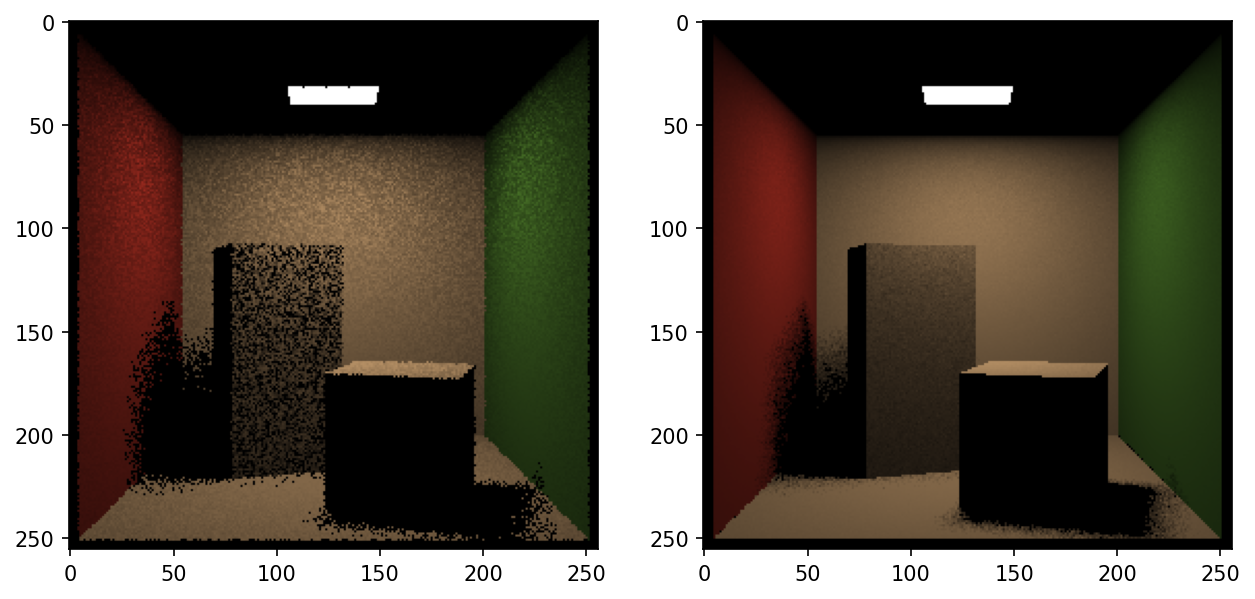

In [11]:
def integrator_sample_em_multiRIS_sharedStream(
        scene: mi.Scene, 
        sampler: mi.Sampler, 
        rays: mi.Ray3f, 
        M_em: int,
        K_slots: int
        ):
    ctx = mi.BSDFContext()
    si = scene.ray_intersect(rays)
    active = si.is_valid()
    bsdf = si.bsdf(rays)
    rsv_em = MultiReservoirDirectionSample3f(dr.width(rays), slot_count = K_slots)

    # Handle direct hit on emitter
    result: mi.Color3f = dr.zeros(mi.Color3f, dr.width(rays))

    # --------------- Sample generation for emitters ---------------
    for _ in range(M_em):
        # Draw an emitter sample, `s`, *without* visibility test
        ds_sample = scene.sample_emitter_direction(
            si, sampler.next_2d(), False)[0]
        # Contrib. weight of drawn sample, `s.W`
        ds_W = dr.rcp(ds_sample.pdf)
        # Compute target function *without* visibility
        em_val = ds_sample.emitter.eval_direction(si, ds_sample)
        p_hat = bsdf.eval(ctx, si, si.to_local(ds_sample.d)) * em_val

        # TODO: had to take the max component of `p_hat` since it contains color values
        p_hat = dr.max(p_hat, axis=0)
        # Compute weight `w`
        mis_weight = 1.0 / M_em
        w = dr.select(ds_sample.pdf > 0.0, p_hat * ds_W * mis_weight, 0.0)      # 50:13
        # Add sample to reservoir
        rsv_em.add_proposal(ds_sample, sampler, w)
        
    for k in range(rsv_em.slot_count):
        ds, w_sum = rsv_em.get_sample(k)
        em_val = ds.emitter.eval_direction(si, ds)
        wo = si.to_local(ds.d)
        # TODO: had to take the max component of `p_hat` since it contains color values
        p_hat = dr.max(bsdf.eval(ctx, si, wo) * em_val, axis=0)
        contrib_weight = dr.select(p_hat > 0.0, w_sum / p_hat, 0.0)   # == "big W"

        # --------------------- Evaluate integrand ----------------------
        bsdf_val = bsdf.eval(ctx, si, wo)
        Le_val = ds.emitter.eval_direction(si, ds)
        # Evaluate visibility
        occluded = scene.ray_test(si.spawn_ray_to(ds.p))
        integrand = dr.select(~occluded, bsdf_val * Le_val, mi.Color3f(0.0))
        result += dr.select(active, integrand * contrib_weight, 0.0)
    result /= rsv_em.slot_count
    result += dr.select(si.emitter(scene) != None, si.emitter(scene).eval(si), mi.Color3f(0.0))


    # # ------ Finalize ------
    return dr.select(si.is_valid(), result, 0.0)


M_em = 32
for K_slots in [1,2,4,8]:
    rays = sensor.sample_ray(0.0, 0.0, mi.Point2f(uu, vv), dr.zeros(mi.Point2f, N))[0]
    sampler = mi.load_dict({'type': 'independent'})
    sampler.seed(0, N)
    image = integrator_sample_em_multiRIS_sharedStream(scene, sampler, rays, M_em, K_slots)
    img_ris_em = mi.TensorXf(dr.ravel(image), shape=(Nx, Ny, 3))
    mi.util.write_bitmap(f"cornell_ris_em={M_em}_slots={K_slots}.exr", img_ris_em)


plt.figure(figsize=(10, 5), dpi=150)
img_gt_1 = mi.render(scene, spp=1)
mi.util.write_bitmap("cornell_gt_1.exr", img_gt_1)
plt.subplot(121); plt.imshow(img_gt_1 ** (1 / 2.2))
plt.subplot(122); plt.imshow(img_ris_em ** (1 / 2.2))


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].


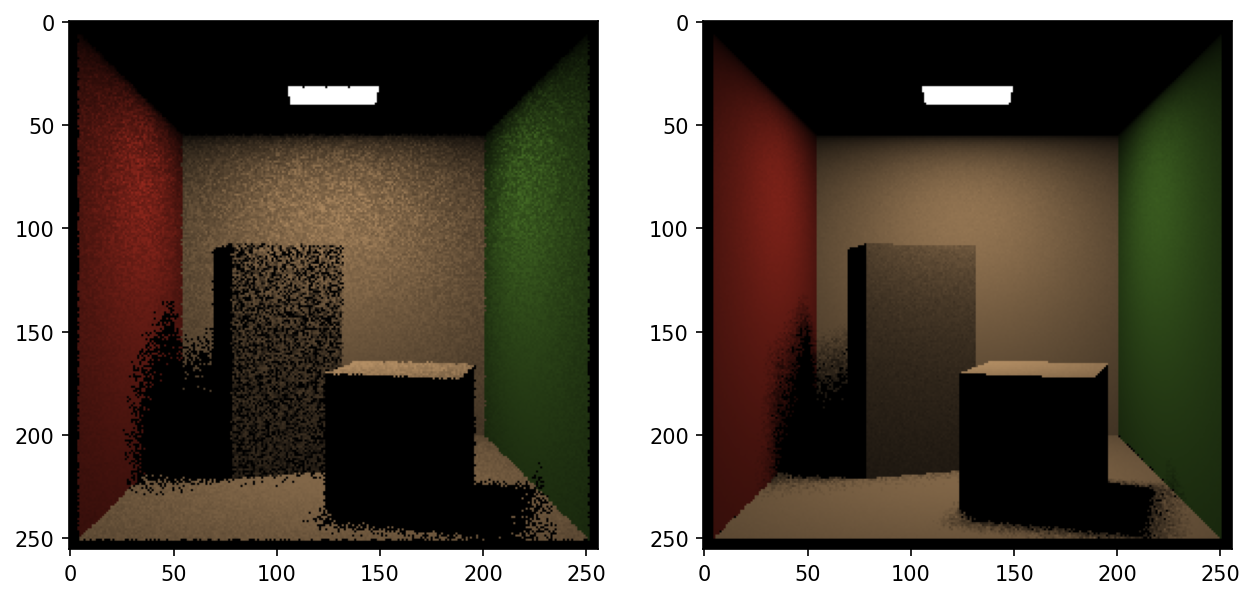

In [36]:
def integrator_sample_em_multiRIS_indepStream(
        scene: mi.Scene, 
        sampler: mi.Sampler, 
        rays: mi.Ray3f, 
        M_em: int,
        K_rsv: int
        ):
    ctx = mi.BSDFContext()
    si = scene.ray_intersect(rays)
    active = si.is_valid()
    bsdf = si.bsdf(rays)

    # Handle direct hit on emitter
    result: mi.Color3f = dr.zeros(mi.Color3f, dr.width(rays))

    rsvs: list[ReservoirDirectionSample3f] = []
    # --------------- Sample generation for emitters ---------------
    for _ in range(K_rsv):
        rsv = ReservoirDirectionSample3f(dr.width(rays))
        for _ in range(M_em):
            # Draw an emitter sample, `s`, *without* visibility test
            ds_sample = scene.sample_emitter_direction(
                si, sampler.next_2d(), False)[0]
            # Contrib. weight of drawn sample, `s.W`
            ds_W = dr.rcp(ds_sample.pdf)
            # Compute target function *without* visibility
            em_val = ds_sample.emitter.eval_direction(si, ds_sample)
            p_hat = bsdf.eval(ctx, si, si.to_local(ds_sample.d)) * em_val

            # TODO: had to take the max component of `p_hat` since it contains color values
            p_hat = dr.max(p_hat, axis=0)
            # Compute weight `w`
            mis_weight = 1.0 / M_em
            w = dr.select(ds_sample.pdf > 0.0, p_hat * ds_W * mis_weight, 0.0)      # 50:13
            # Add sample to reservoir
            rsv.add_proposal(ds_sample, sampler.next_1d(), w)
        rsvs.append(rsv)
            
    for rsv in rsvs:
        ds, contrib_weight = rsv.get_sample(lambda ds: eval_target_function(ds, si, bsdf))

        # ds, w_sum = rsv.get_sample()
        # em_val = ds.emitter.eval_direction(si, ds)
        wo = si.to_local(ds.d)
        # # TODO: had to take the max component of `p_hat` since it contains color values
        # p_hat = dr.max(bsdf.eval(ctx, si, wo) * em_val, axis=0)
        # contrib_weight = dr.select(p_hat > 0.0, w_sum / p_hat, 0.0)   # == "big W"

        # --------------------- Evaluate integrand ----------------------
        bsdf_val = bsdf.eval(ctx, si, wo)
        Le_val = ds.emitter.eval_direction(si, ds)
        # Evaluate visibility
        occluded = scene.ray_test(si.spawn_ray_to(ds.p))
        integrand = dr.select(~occluded, bsdf_val * Le_val, mi.Color3f(0.0))
        result += dr.select(active, integrand * contrib_weight, 0.0)
    result /= K_rsv
    result += dr.select(si.emitter(scene) != None, si.emitter(scene).eval(si), mi.Color3f(0.0))

    # # ------ Finalize ------
    return dr.select(si.is_valid(), result, 0.0)


M_em = 8
for K_slots in [1,2,4,8]:
    rays = sensor.sample_ray(0.0, 0.0, mi.Point2f(uu, vv), dr.zeros(mi.Point2f, N))[0]
    sampler = mi.load_dict({'type': 'independent'})
    sampler.seed(0, N)
    image = integrator_sample_em_multiRIS_indepStream(scene, sampler, rays, M_em, K_slots)
    img_ris_em = mi.TensorXf(dr.ravel(image), shape=(Nx, Ny, 3))
    mi.util.write_bitmap(f"cornell_ris_em={M_em}_slots={K_slots}.exr", img_ris_em)


plt.figure(figsize=(10, 5), dpi=150)
img_gt_1 = mi.render(scene, spp=1)
mi.util.write_bitmap("cornell_gt_1.exr", img_gt_1)
plt.subplot(121); plt.imshow(img_gt_1 ** (1 / 2.2))
plt.subplot(122); plt.imshow(img_ris_em ** (1 / 2.2))


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.7564507].
Clipping input data to the valid r

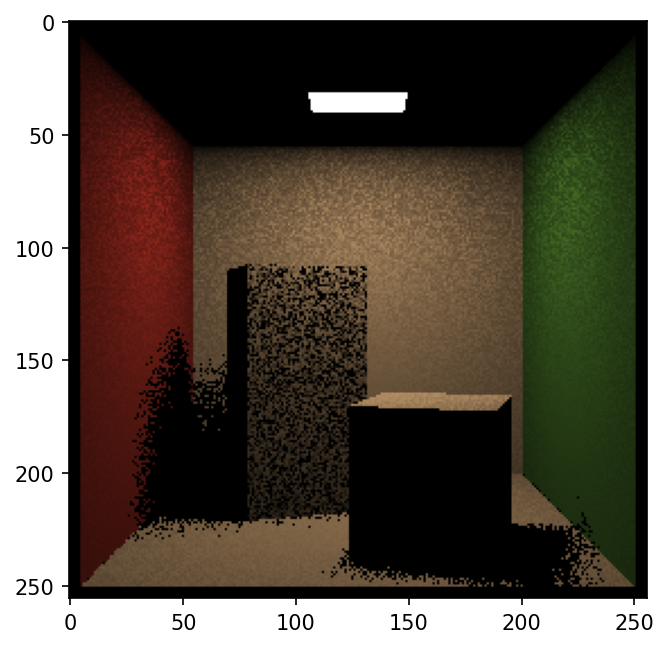

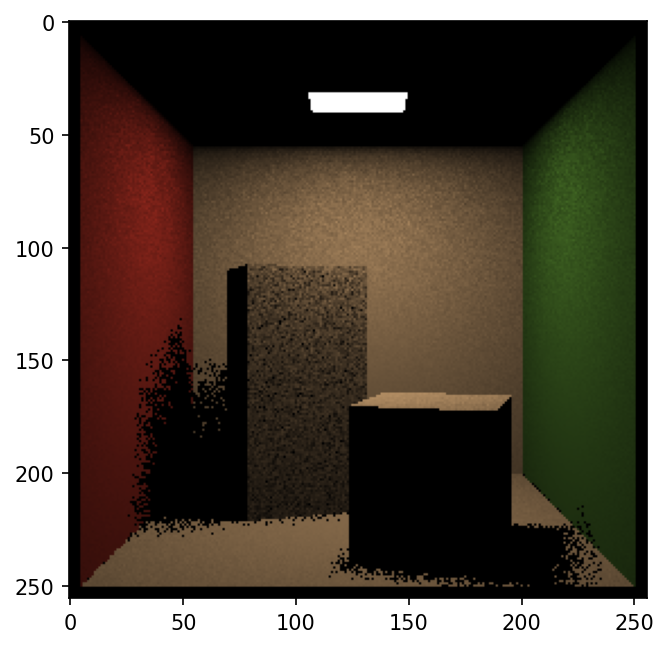

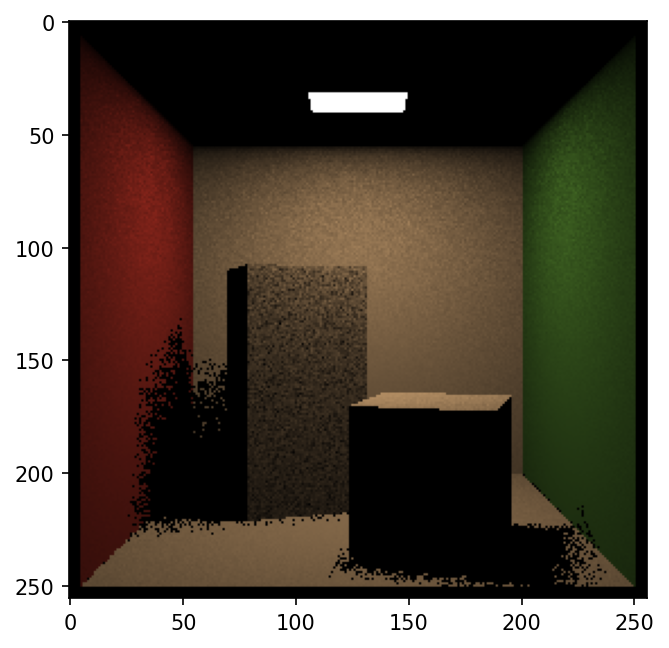

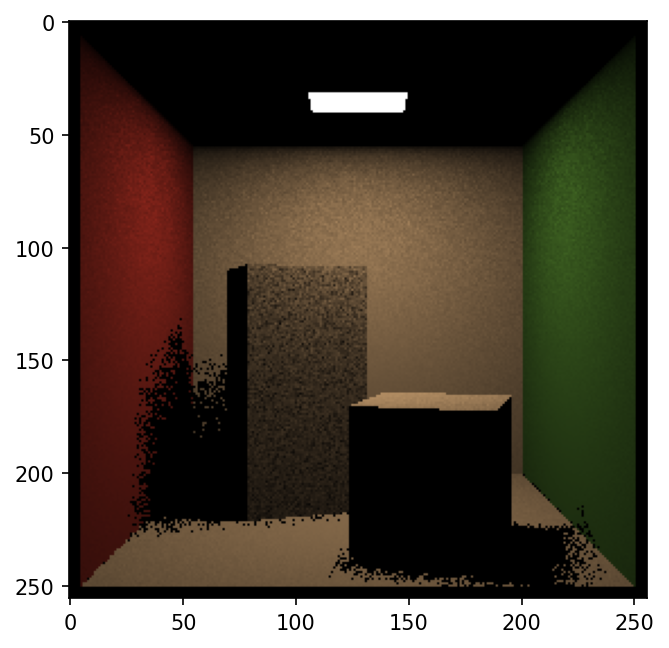

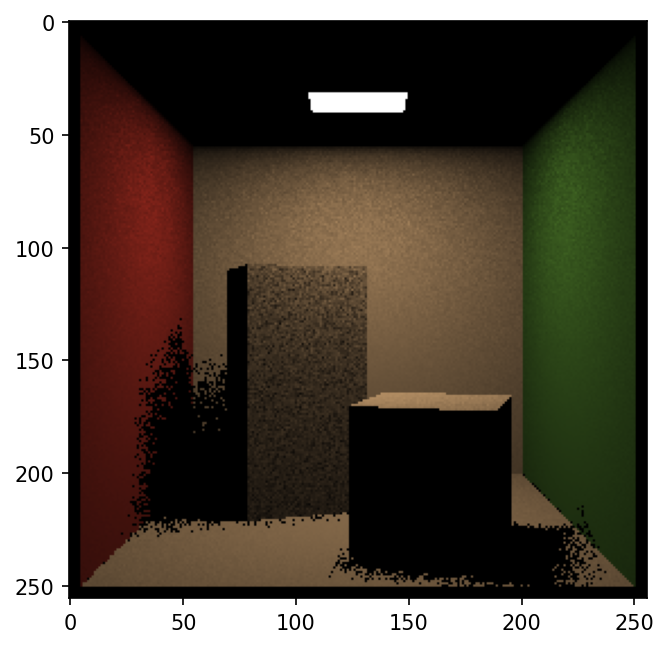

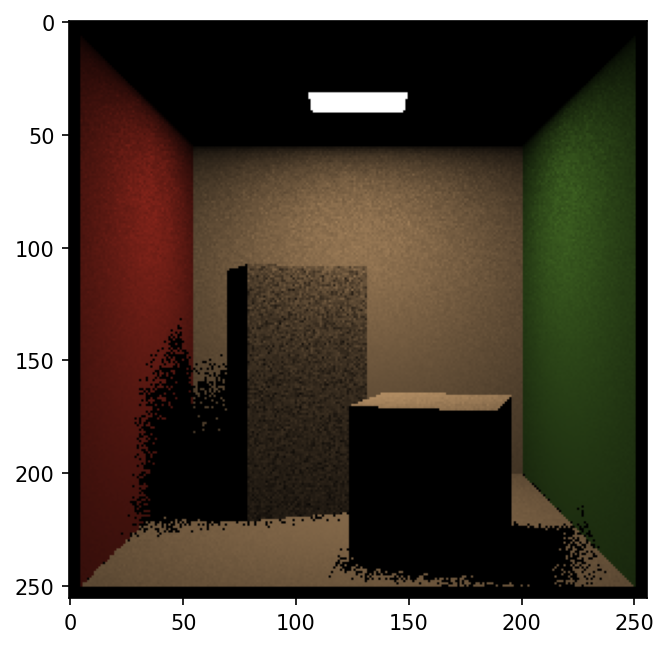

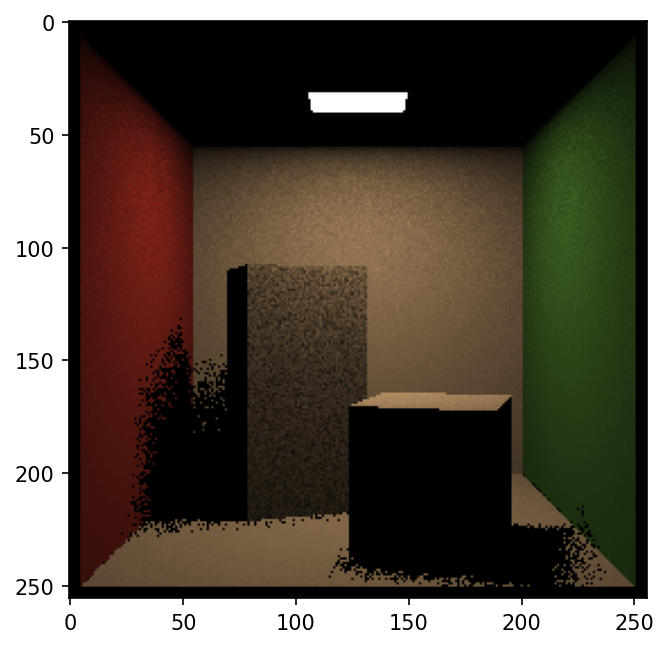

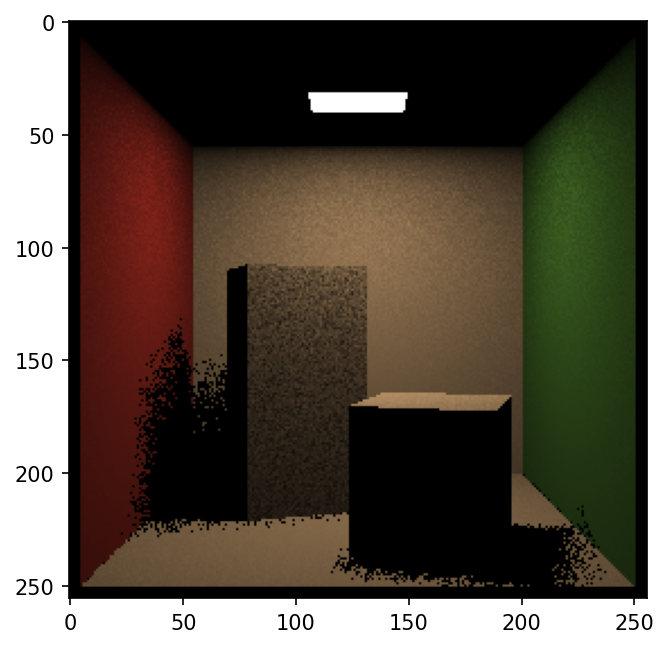

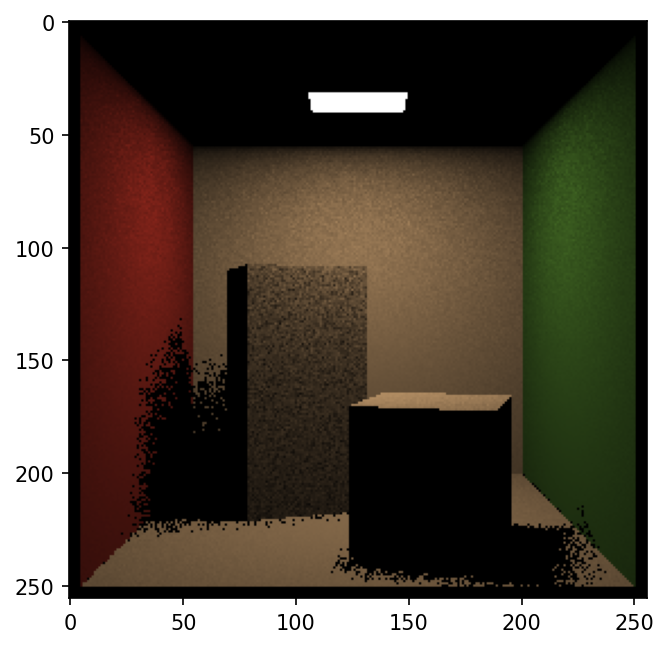

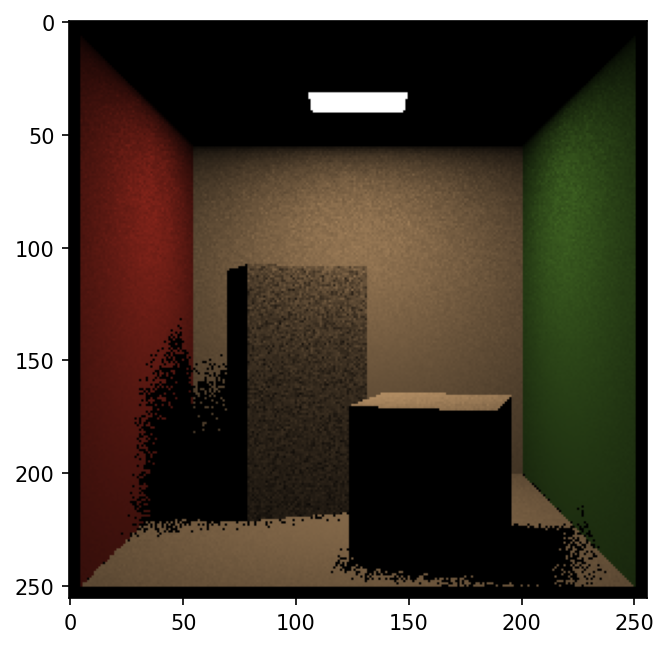

In [77]:
def initialize(scene) -> tuple[mi.Sampler, mi.Ray3f]:
    sensor: mi.Sensor = scene.sensors()[0]
    Ny, Nx = sensor.film().size()
    N = Ny * Nx
    uu, vv = dr.meshgrid(
        dr.linspace(Float, 0.0, 1.0, Ny), 
        dr.linspace(Float, 0.0, 1.0, Nx))
    rays = sensor.sample_ray(0.0, 0.0, mi.Point2f(uu, vv), dr.zeros(mi.Point2f, N))[0]
    sampler = mi.load_dict({'type': 'independent'})
    sampler.seed(0, N)
    return sampler, rays


def emRIS(scene: mi.Scene, sampler: mi.Sampler, rays: mi.Ray3f, M_em: int, rsv_prev: ReservoirDirectionSample3f = None):
    ctx = mi.BSDFContext()
    si = scene.ray_intersect(rays)
    active = si.is_valid()
    bsdf = si.bsdf(rays)

    # Handle direct hit on emitter
    result: mi.Color3f = dr.select(si.emitter(scene) != None, si.emitter(scene).eval(si), mi.Color3f(0.0))

    # --------------- Sample generation for emitters ---------------
    # Populate `rsv_curr` with the current iteration's proposals/candidates
    rsv_curr = ReservoirDirectionSample3f(dr.width(rays))
    for _ in range(M_em):
        # Draw an emitter sample, `s`, *without* visibility test
        ds_sample = scene.sample_emitter_direction(
            si, sampler.next_2d(), False)[0]
        # Contrib. weight of drawn sample, `s.W`
        ds_W = dr.rcp(ds_sample.pdf)
        # Compute `p_hat`: target function *without* visibility
        p_hat = eval_target_function(ds_sample, si, bsdf)
        # Compute weight `w`
        mis_weight = 1.0 / M_em
        w = dr.select(ds_sample.pdf > 0.0, mis_weight * p_hat * ds_W, 0.0)
        # Add sample to reservoir
        rsv_curr.add_proposal(ds_sample, sampler.next_1d(), w, 1.0)
    rsv_curr.eval_target(lambda ds: eval_target_function(ds, si, bsdf))

    if rsv_prev is not None:
        # --------------- Temporal reuse ---------------
        # Adjust `rsv_curr` to account for the addition of the previous iteration's 
        # reservoir. Then, merge it with this previous reservoir.

        # prev_c = dr.minimum(rsv_prev.c, 20.0 * rsv_curr.c)

        # mis_curr = power_heuristic(
        #     rsv_curr.eval_target(rsv_curr.sample) * rsv_curr.c, 
        #     rsv_prev.eval_target(rsv_curr.sample) * rsv_prev.c) 

        # TODO/NOTE: the probabilities need to be evaluated on the *respective samples* and 
        # *their respective p_hat distributions*!
        #       e.g. for `mis_curr`, the `curr.p_hat` and `prev.p_hat` should be evaluated 
        #       on `curr.sample` using `p_hat_curr(x)` and `p_hat_prev(x)`

        # In the case that the function `p_hat` doesn't change between frames, the balance 
        # heuristic can be greatly simplified:
        #
        # mis_weight = (p_curr(x_curr) * c_curr) / (p_curr(x_curr) * c_curr + p_prev(x_curr) * c_prev)
        #            = (p(x_curr) * c_curr) / (p(x_curr) * (c_curr + c_prev))
        #            = c_curr / (c_curr + c_prev)
        #
        # *WARNING*: this only applies if we do purely temporal reuse!!! If spatial reuse is
        # added too, `p_prev(x)` will come from a *spatial* neighbor in the previous timestep,
        # which is almost certain to have a different distribution than `p_curr(x)`

        mis_curr = power_heuristic(rsv_curr.c, rsv_prev.c)

        rsv_curr.reinitialize(mis_curr)

        # Add previous iteration's reservoir
        mis_prev = power_heuristic(rsv_prev.c, rsv_curr.c)
        w = dr.select(rsv_prev.p_hat > 0.0, mis_prev * rsv_prev.w_sum, 0.0)
        rsv_curr.add_proposal(rsv_prev.sample, sampler.next_1d(), w, rsv_prev.c)

        # return mi.Color3f(mis_curr, mis_curr, mis_curr), rsv_curr
    
    # Draw sample from the reservoir
    ds, contrib_weight = rsv_curr.get_sample(lambda ds: eval_target_function(ds, si, bsdf))

    # --------------------- Evaluate integrand ----------------------
    wo = si.to_local(ds.d)
    bsdf_val = bsdf.eval(ctx, si, wo)
    Le_val = ds.emitter.eval_direction(si, ds)
    # Evaluate visibility
    occluded = scene.ray_test(si.spawn_ray_to(ds.p))
    integrand = dr.select(~occluded, bsdf_val * Le_val, mi.Color3f(0.0))
    result += dr.select(active, integrand * contrib_weight, 0.0)

    # # ------ Finalize ------
    return dr.select(si.is_valid(), result, 0.0), rsv_curr


M_em = 1
N_frames = 30
sampler, rays = initialize(scene)
image, rsv_prev = emRIS(scene, sampler, rays, M_em)
plt.figure(figsize=(10, 5), dpi=150)
image = mi.TensorXf(dr.ravel(image), shape=(Nx, Ny, 3))
mi.util.write_bitmap("itr0.exr", image)
plt.imshow(image ** (1 / 2.2))

for i in range(1, N_frames):
    image, rsv_curr = emRIS(scene, sampler, rays, M_em, rsv_prev)
    rsv_prev = rsv_curr

    if i % 3 == 0:
        plt.figure(figsize=(10, 5), dpi=150)
        image = mi.TensorXf(dr.ravel(image), shape=(Nx, Ny, 3))
        mi.util.write_bitmap(f"itr{i}.exr", image)
        plt.imshow(image ** (1 / 2.2))
